# Marketing Funnel & Conversion Performance Analysis (eCommerce User Behavior Study)

## Objective
Analyze user behavior across the eCommerce funnel (view → cart → purchase) to identify conversion rates, drop-off points, and behavioral patterns in customer journeys. The goal is to generate insights that can help optimize engagement and improve conversion performance.

## Import Libraries

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_context("talk")


## Load Dataset

In [21]:

df = pd.read_csv(r"C:\Users\Monwabisi05\IdeaProjects\DATA SCIENCE_FUTURE_DS_01\TASK_THREE\data_backup\2019-Oct.csv", nrows=100000)
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


## Data Overview

In [22]:
df.info()
df['event_type'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     100000 non-null  object 
 1   event_type     100000 non-null  object 
 2   product_id     100000 non-null  int64  
 3   category_id    100000 non-null  int64  
 4   category_code  67413 non-null   object 
 5   brand          85607 non-null   object 
 6   price          100000 non-null  float64
 7   user_id        100000 non-null  int64  
 8   user_session   100000 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 6.9+ MB


event_type
view        97130
purchase     1655
cart         1215
Name: count, dtype: int64

The dataset contains event-level user interactions in an eCommerce platform, including product views, cart additions, and purchases. Analysis is performed on a sample of 100,000 records.

## Data Preparation 

In [25]:
df['event_time'] = pd.to_datetime(df['event_time'])

## Funnel Definition
This analysis defines a simplified eCommerce funnel based on user interaction events:

- View: User views a product
- Cart: User adds product to cart
- Purchase: User completes a transaction

The funnel is analyzed at the session level to better reflect user journeys.

## Funnel Counts

In [32]:
# Keep only relevant events
funnel_df = df[df['event_type'].isin(['view', 'cart', 'purchase'])]

# Count unique sessions per stage
visitors = funnel_df[funnel_df['event_type'] == 'view']['user_session'].nunique()
carts = funnel_df[funnel_df['event_type'] == 'cart']['user_session'].nunique()
purchases = funnel_df[funnel_df['event_type'] == 'purchase']['user_session'].nunique()

visitors, carts, purchases

(24376, 798, 1431)

### Insight
The funnel analysis is based on unique user sessions to better capture individual browsing and purchase journeys rather than raw event counts. The number of customers exceeds users who added items to cart, indicating that purchases may occur without a cart step.

## Session-based funnel

In [45]:
funnel = df[df['event_type'].isin(['view','cart','purchase'])]

session_funnel = pd.crosstab(
    funnel['user_session'],
    funnel['event_type']
).fillna(0)

session_funnel.head()

event_type,cart,purchase,view
user_session,,,
00056e5c-f5b0-464b-84d0-d5d02197c4da,0,0,2
0006852b-f9a2-4d84-b439-acc1f9e6771e,0,0,1
000c2fd2-561a-4abd-bd21-5e71449b1b78,0,0,2
000c8aaa-d614-433a-9621-a53629f39fd9,0,0,1
001259d1-d126-4601-a53e-b511cf3a3152,0,0,1


This transformation allows the funnel to be analyzed at the session level, ensuring a more realistic representation of user journeys.

## Conversion Rates

In [47]:
visitors = (session_funnel['view'] > 0).sum()
carts = (session_funnel['cart'] > 0).sum()
purchases = (session_funnel['purchase'] > 0).sum()

visit_to_cart = (carts / visitors) * 100
visit_to_purchase = (purchases / visitors) * 100

visitors, carts, purchases, visit_to_cart, visit_to_purchase

(np.int64(24376),
 np.int64(798),
 np.int64(1431),
 np.float64(3.273711847719068),
 np.float64(5.87052838857893))

### Insight
The conversion results indicate a non-linear funnel structure, where users are not required to pass through the cart stage before completing a purchase. This explains why purchase counts exceed cart interactions.

## Drop-off Analysis

In [31]:
drop_off_rate = 100 - visit_to_purchase
drop_view_to_cart = 100 - visit_to_cart

drop_off_rate, drop_view_to_cart

(93.44551832409361, 96.35480547515085)

### Insight
The analysis shows a significant drop-off between product views and subsequent actions, with over 93% of users not completing a purchase. The highest attrition occurs at the top of the funnel (view stage), indicating weak product engagement or low purchase intent among users.

## Price Analysis

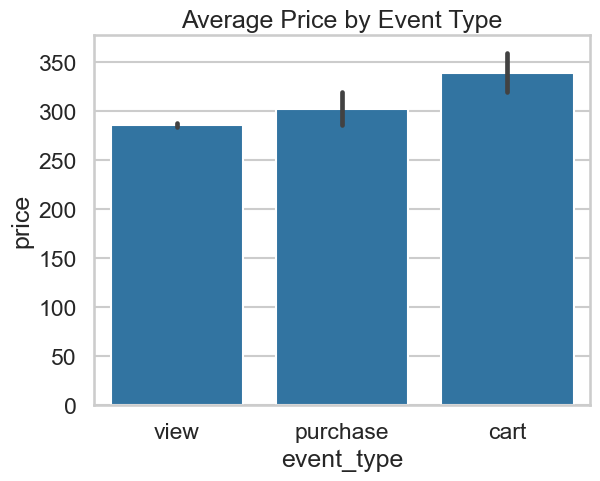

In [50]:
sns.barplot(data=df, x='event_type', y='price', estimator='mean')
plt.title("Average Price by Event Type")
plt.show()

### Insight
Price distribution analysis shows that higher-priced products attract substantial user attention but exhibit lower conversion rates. This suggests price sensitivity among users and highlights the need for pricing optimization or value communication strategies.

## Catagory Analysis

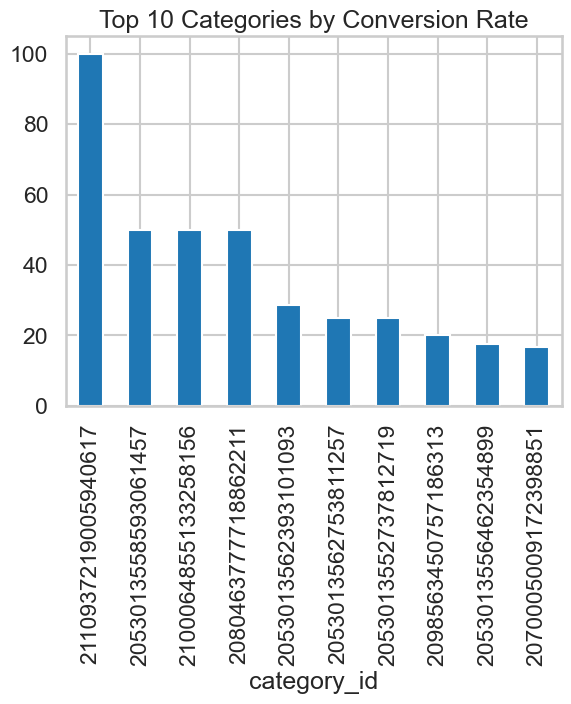

In [52]:
category_conversion['conversion_rate'] = (
    category_conversion['purchase'] / category_conversion['view']
) * 100

top_categories = category_conversion.sort_values('conversion_rate', ascending=False).head(10)

top_categories['conversion_rate'].plot(kind='bar')
plt.title("Top 10 Categories by Conversion Rate")
plt.show()

### Insight
Conversion performance varies significantly across product categories, indicating differences in user intent, product attractiveness, and market demand. Certain categories demonstrate stronger conversion efficiency, suggesting better alignment with user needs.

## Key Insights

- High drop-off rate (~93%) indicates low conversion efficiency
- Majority of users do not progress beyond the viewing stage
- Purchase behavior does not strictly depend on cart activity
- High-priced products attract attention but convert less
- Conversion performance varies significantly across product categories

## Recommendations

- Improve product page engagement to increase progression from view to cart
- Optimize pricing strategy for high-value products to reduce drop-off
- Enhance checkout experience to support both cart-based and direct purchases
- Focus marketing efforts on high-converting categories to maximize ROI
- Improve product recommendation systems to increase user engagement depth

## Conclusion

This analysis highlights inefficiencies in the eCommerce conversion funnel, particularly at the product viewing stage. The presence of non-linear purchase behavior and strong variation across categories suggests opportunities for improving engagement, pricing strategy, and user experience. Addressing these areas can significantly enhance conversion rates and overall revenue performance.